## Importing Libraries

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Importing the dataset

In [127]:
df = pd.read_csv("/content/drive/MyDrive/NBICT LAB PDSML-B-8/10. Yield Prediction/Yield.csv")

In [128]:
df

,Entity,Code,Year,yield_t_ha,fertilizer_kg_ha,rainfall_mm,temperature_c
0,Afghanistan,AFG,1961,1.1151,0.143791,375.61630,11.336086
1,Afghanistan,AFG,1962,1.0790,0.142857,297.93750,11.144688
2,Afghanistan,AFG,1963,0.9858,0.141935,340.40457,12.411133
3,Afghanistan,AFG,1964,1.0828,0.141026,381.36438,10.428821
4,Afghanistan,AFG,1965,1.0989,0.141026,387.33570,11.212724
...,...,...,...,...,...,...,...
9163,Zimbabwe,ZWE,2019,0.7496,32.932423,608.31180,22.434418
9164,Zimbabwe,ZWE,2020,1.1505,20.196915,814.14435,21.785585
9165,Zimbabwe,ZWE,2021,1.5459,36.868920,788.98170,21.573133
9166,Zimbabwe,ZWE,2022,0.8308,30.780697,774.35420,21.591951


## Visualizing Relationships


### Yield vs Fertilizers

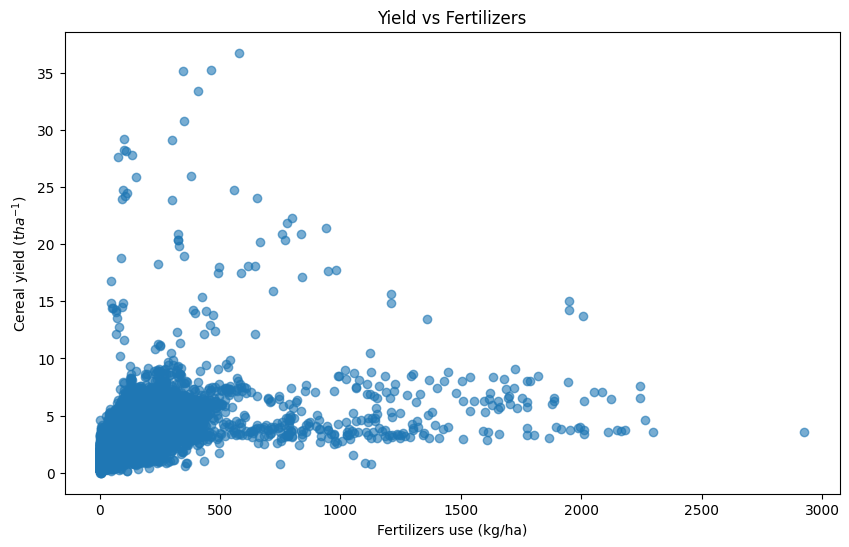

In [129]:
plt.figure(figsize=(10,6))

plt.scatter(df['fertilizer_kg_ha'], df['yield_t_ha'], alpha= 0.6)
plt.xlabel('Fertilizers use (kg/ha)')
plt.ylabel('Cereal yield (t$ha^{-1}$)')
plt.title('Yield vs Fertilizers')

plt.show()

### Yield vs Rainfall

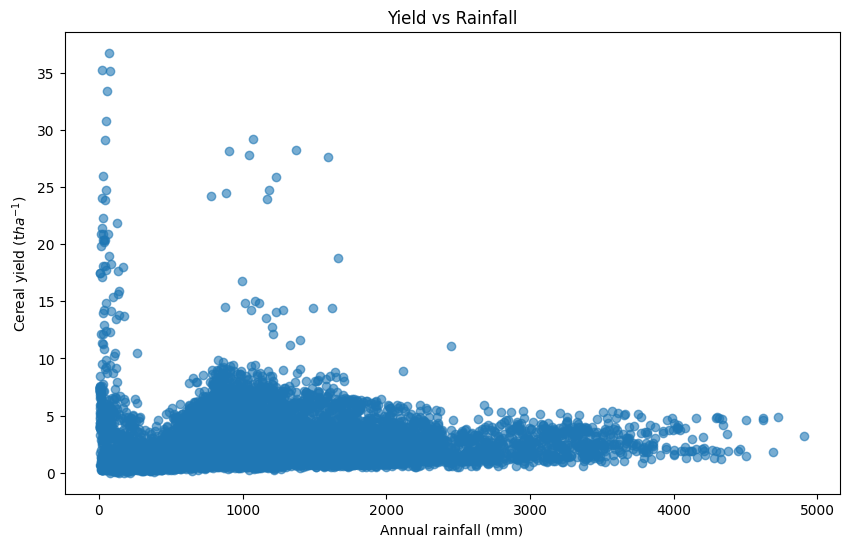

In [130]:
plt.figure(figsize=(10,6))

plt.scatter(df['rainfall_mm'], df['yield_t_ha'], alpha= 0.6)
plt.xlabel('Annual rainfall (mm)')
plt.ylabel('Cereal yield (t$ha^{-1}$)')
plt.title('Yield vs Rainfall')

plt.show()

### Yield vs Temparature

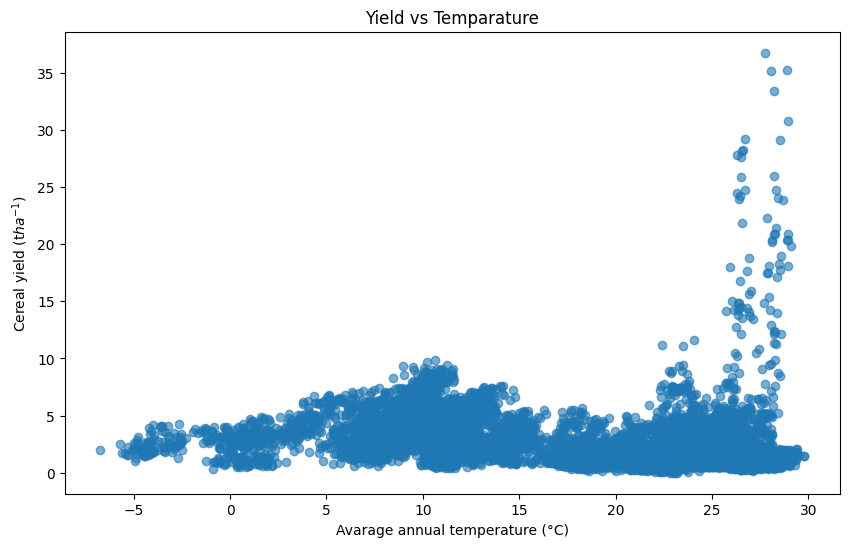

In [131]:
plt.figure(figsize=(10,6))

plt.scatter(df['temperature_c'], df['yield_t_ha'], alpha= 0.6)
plt.xlabel('Avarage annual temperature (°C)') #degree find with (windose + R) and then charmap and run
plt.ylabel('Cereal yield (t$ha^{-1}$)')
plt.title('Yield vs Temparature')

plt.show()

## Checking correlations

In [132]:
corr = df[["yield_t_ha", "fertilizer_kg_ha", "rainfall_mm", "temperature_c"]].corr()

In [133]:
print(corr)

                  yield_t_ha  fertilizer_kg_ha  rainfall_mm  temperature_c
yield_t_ha          1.000000          0.454181    -0.005341      -0.229801
fertilizer_kg_ha    0.454181          1.000000     0.093129      -0.158104
rainfall_mm        -0.005341          0.093129     1.000000       0.181796
temperature_c      -0.229801         -0.158104     0.181796       1.000000


## Separating features from the target

In [134]:
X = df[['fertilizer_kg_ha', 'rainfall_mm', 'temperature_c']]
y = df['yield_t_ha']

## Splitting the dataset into the training set and test set

In [135]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

## Building a simple baseline model

## Training the model

In [136]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

## Predecting the test set result

In [137]:
y_pred = linear_model.predict(X_test)

## Baseline model evaluation

In [138]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error:, {mae: .2f}")
print(f"Root Mean Squared Error:, {rmse: .2f}")
print(f"R-squared Value:, {r2: .2f}")

Mean Absolute Error:,  1.22
Root Mean Squared Error:,  2.22
R-squared Value:,  0.22


The independent variable explain 22% of the dependent vector.

## For understanding

In [139]:
#Calculate error
error = y_test - y_pred
# absulute value
abs_error = error.abs()
mae_manual = abs_error.mean()
print(mae_manual)

1.2152393727758077


mean absolute error, lower is better....
the threshold is depend on the min and max yield.

In [140]:
# Root Mean Square Error
squ_error = error ** 2
root_square_error = (squ_error.mean()) ** 0.5
rmse_manual = root_square_error.mean()
print(rmse_manual)

2.2154978331013946


when,

rmse<mae --> this is satisfactory model. otherwise weak model.

coefficient -> how much change occur in x if the one unit of change happen in y.

In [141]:
linear_model.coef_

array([ 4.33530171e-03, -3.17814110e-05, -5.06050164e-02])

In [142]:
pd.DataFrame({
    "feature" : X.columns,
    "coefficient" : linear_model.coef_
})

,feature,coefficient
0,fertilizer_kg_ha,0.004335
1,rainfall_mm,-0.000032
2,temperature_c,-0.050605


In [143]:
import statsmodels.api as sm
X_const = sm.add_constant(X)
ols_model = sm.OLS(y, X_const).fit()

In [144]:
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:             yield_t_ha   R-squared:                       0.232
Model:                            OLS   Adj. R-squared:                  0.232
Method:                 Least Squares   F-statistic:                     923.5
Date:                Thu, 09 Jul 2026   Prob (F-statistic):               0.00
Time:                        11:04:45   Log-Likelihood:                -19762.
No. Observations:                9168   AIC:                         3.953e+04
Df Residuals:                    9164   BIC:                         3.956e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                3.0480      0.064  

Firstly F_stat less than 0.05 --> thats good.

The adj r-squared is 0.23 means the independent factors can explan 23% variability of the yield.

constant --> when everything zero, means without the any influences of the independent factor how much we get the yield. some dataset constant is just misleading means. we cannot implement 0 degree celcious.

coef. **the value** and is this **statistical significant**..?


## Decision Tree Regression Python Implementation

In [145]:
from sklearn.tree import DecisionTreeRegressor

In [146]:
#Building the model
tree_model = DecisionTreeRegressor(
    max_depth = 10,
    min_samples_leaf = 50, # Stops overfitting
    random_state = 42
)

# Training the model
tree_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10, min_samples_leaf=50, random_state=42)

### Making Prediction

In [147]:
y_pred_tree = tree_model.predict(X_test)

In [148]:
# Placing the predictied yields and actual yields side by side column
pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_tree
})


,Actual,Predicted
3747,6.659101,3.503290
5949,0.891300,1.766512
4216,1.844400,2.643138
7273,1.174200,0.739127
7061,1.015000,1.533263
...,...,...
2604,1.733900,2.740355
444,4.173900,4.010190
3000,1.511700,1.433786
8384,1.117900,1.330074


## Evaluating the model

In [149]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = mean_squared_error(y_test, y_pred_tree) ** 0.5
r2_tree = r2_score(y_test, y_pred_tree)

print(f"Mean Absolute Error: {mae_tree: .2f}")
print(f"Root Mean Squared Error: {rmse_tree: .2f}")
print(f"R-squared Value: {r2_tree: .2f}")

Mean Absolute Error:  0.86
Root Mean Squared Error:  1.68
R-squared Value:  0.56
